In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
orders = pd.read_csv("../data/processed/shopee_orders_thailand.csv")
order_items = pd.read_csv("../data/processed/shopee_order_items_thailand.csv")
customers = pd.read_csv("../data/processed/shopee_customers_thailand.csv")
products = pd.read_csv("../data/processed/shopee_products_thailand.csv")
sellers = pd.read_csv("../data/processed/shopee_sellers_thailand.csv")
campaigns = pd.read_csv("../data/processed/shopee_campaigns_thailand.csv")
shipments = pd.read_csv("../data/processed/shopee_shipments_thailand.csv")

TỔNG QUAN DỮ LIỆU

In [8]:
datasets = {
    "orders": orders,
    "order_items": order_items,
    "customers": customers,
    "products": products,
    "sellers": sellers,
    "campaigns": campaigns,
    "shipments": shipments
}

for name, df in datasets.items():
    print(name, df.shape)

orders (300000, 11)
order_items (480481, 16)
customers (60000, 10)
products (4880, 8)
sellers (200, 12)
campaigns (20, 5)
shipments (360187, 6)


DOANH THU THEO NGÀY

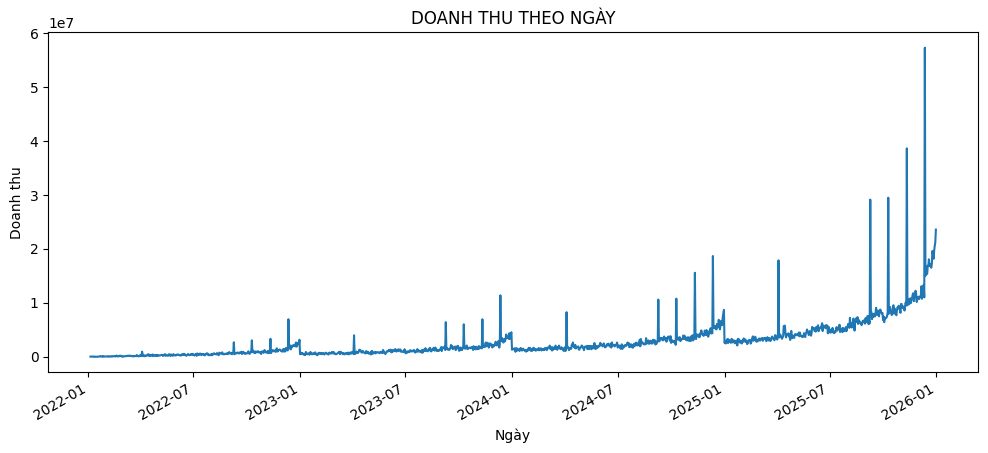

In [12]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

daily_revenue = orders.groupby("order_date")["total_amount"].sum()

daily_revenue.plot(figsize=(12,5))
plt.title("DOANH THU THEO NGÀY")
plt.xlabel("Ngày")
plt.ylabel("Doanh thu")
plt.show()

TOP DANH MỤC SẢN PHẨM BÁN CHẠY THEO SỐ LƯỢNG ĐƠN HÀNG

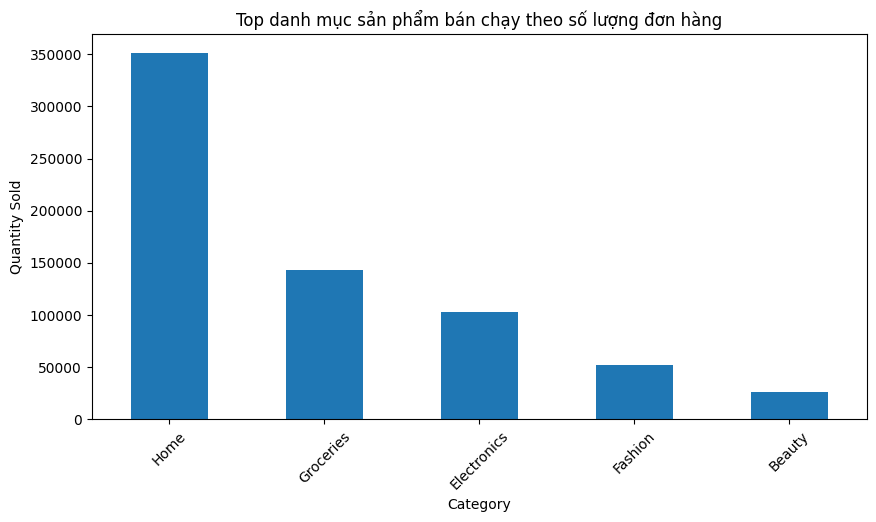

In [15]:
merged_df = order_items.merge(
    products,
    on="product_id",
    how="left"
)

top_categories = (
    merged_df.groupby("category")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
top_categories.plot(kind="bar")
plt.title("Top danh mục sản phẩm bán chạy theo số lượng đơn hàng")
plt.xlabel("Category")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

KHÁCH HÀNG THEO ĐỘ TUỔI

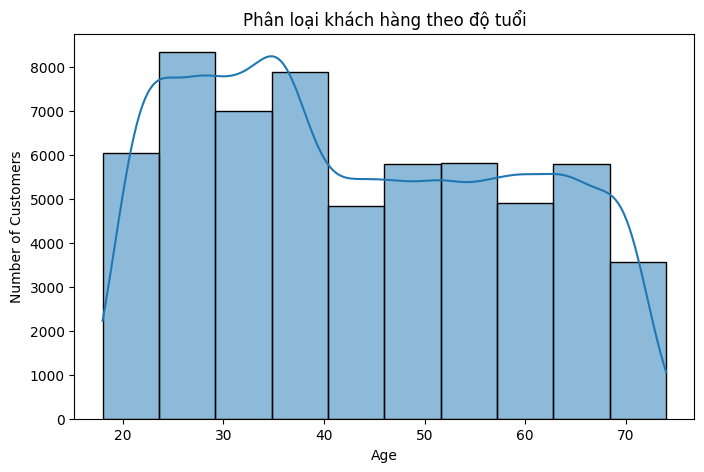

In [24]:
customers["dob"] = pd.to_datetime(customers["dob"])

today = pd.to_datetime("today")

customers["age"] = today.year - customers["dob"].dt.year - (
    (today.month < customers["dob"].dt.month) |
    ((today.month == customers["dob"].dt.month) & (today.day < customers["dob"].dt.day))
)

customers["age_group"] = pd.cut(
    customers["age"],
    bins=[0, 18, 25, 35, 45, 60, 100],
    labels=["<18", "18-25", "26-35", "36-45", "46-60", "60+"]
)

plt.figure(figsize=(8,5))
sns.histplot(customers["age"], bins=10, kde=True)

plt.title("Phân loại khách hàng theo độ tuổi")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

TOP SELLER

In [22]:
products.columns
sellers.columns

Index(['seller_id', 'shop_name', 'seller_type', 'email', 'contact_phone',
       'province', 'city', 'join_date', 'status', 'fbs_standard',
       'use_logistics', 'warehouse'],
      dtype='str')

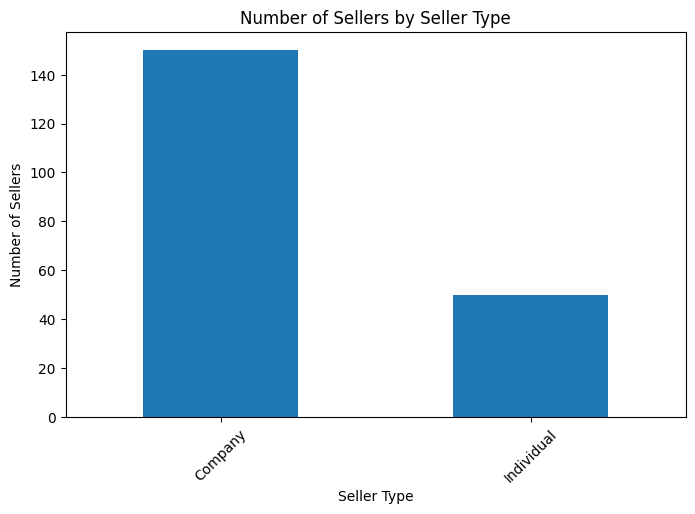

In [23]:
seller_type_count = sellers["seller_type"].value_counts()

plt.figure(figsize=(8,5))
seller_type_count.plot(kind="bar")

plt.title("Number of Sellers by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Number of Sellers")
plt.xticks(rotation=45)
plt.show()